QUESTION 2: Data Visualization and Analysis from Excel File

PART A: Reading Excel File and Creating Visualizations

Excel file loaded successfully from: ../data/algorithm_times.xlsx

DataFrame shape: 6 rows × 4 columns

DataFrame contents:
   Run time for different data size  Alg.1  Alg.2  Alg.3
0                             100KB     50    200    100
1                             200KB     55    220    200
2                             300KB     60    240    300
3                             400KB     65    260    400
4                             500KB     70    280    500
5                             600KB     75    300    600

Column names detected:
   Run time for different data size: ['100KB' '200KB' '300KB' '400KB' '500KB' '600KB']
  Alg.1: [50 55 60 65 70 75]
  Alg.2: [200 220 240 260 280 300]
  Alg.3: [100 200 300 400 500 600]

--------------------------------------------------------------------------------
Creating Bar Chart...
----------------------------------------------

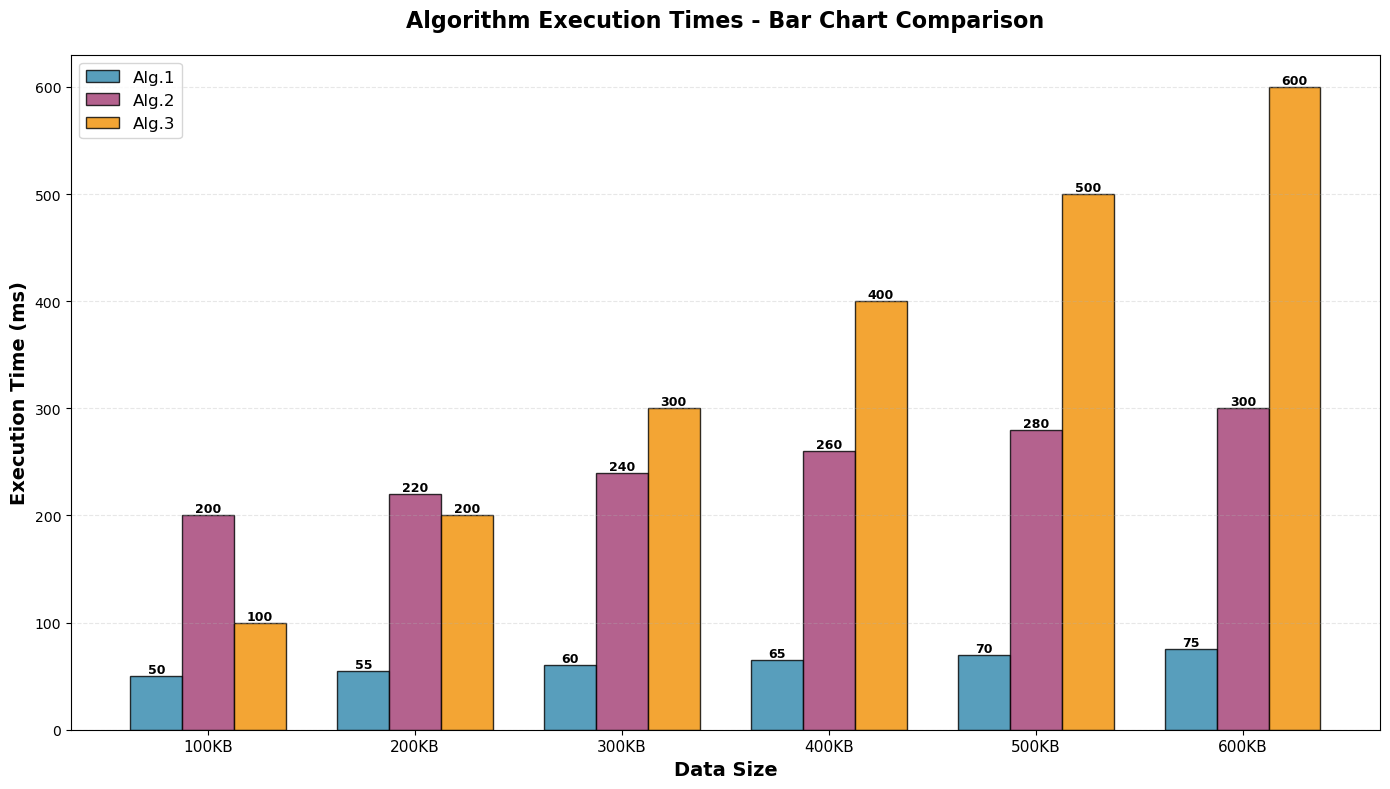


--------------------------------------------------------------------------------
Creating Line Chart...
--------------------------------------------------------------------------------
Line chart saved to: ../outputs/figures/question2_line_chart.png


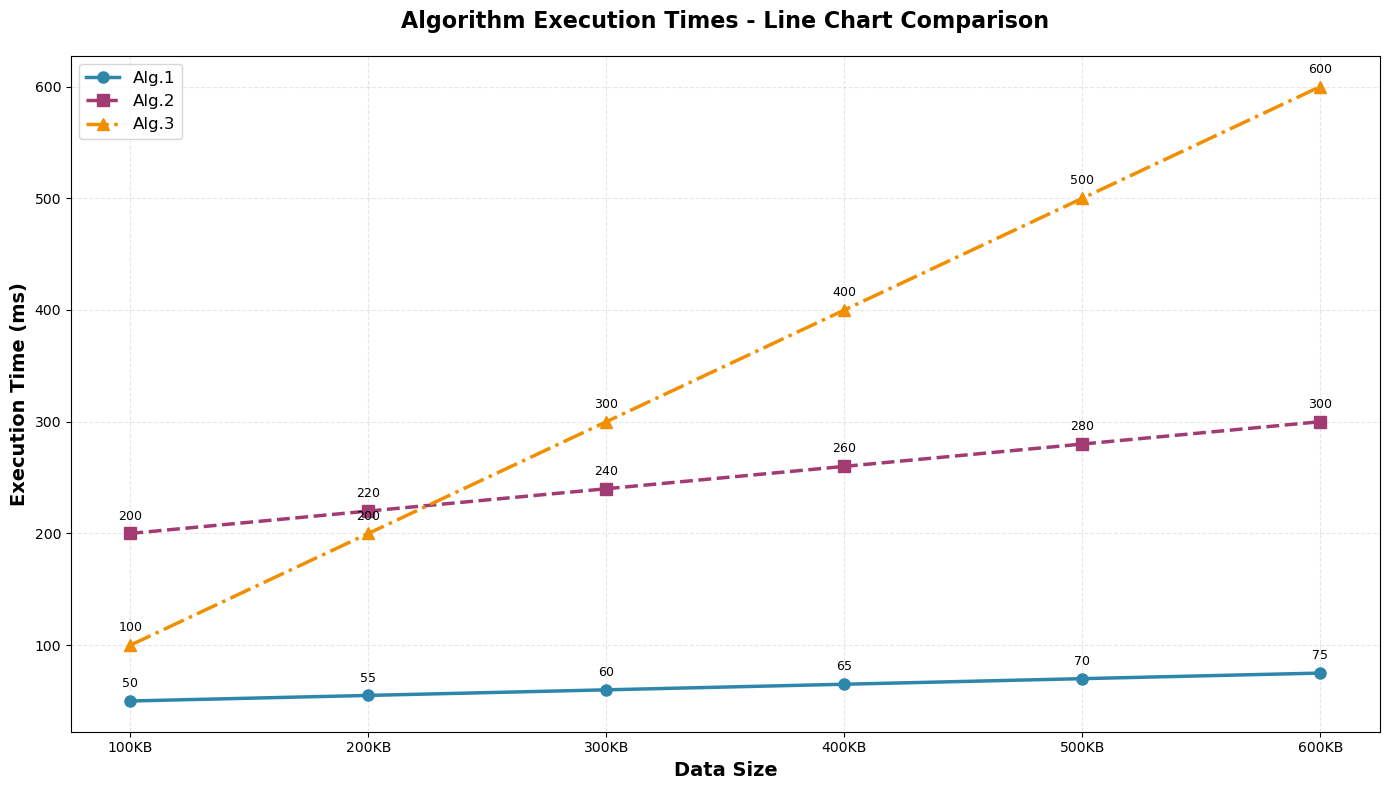


--------------------------------------------------------------------------------
Creating Box Plot...
--------------------------------------------------------------------------------


/var/folders/pm/pw42yk0s04qfkht48phb737c0000gn/T/ipykernel_56358/796038231.py:142: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True,


Box plot saved to: ../outputs/figures/question2_box_plot.png


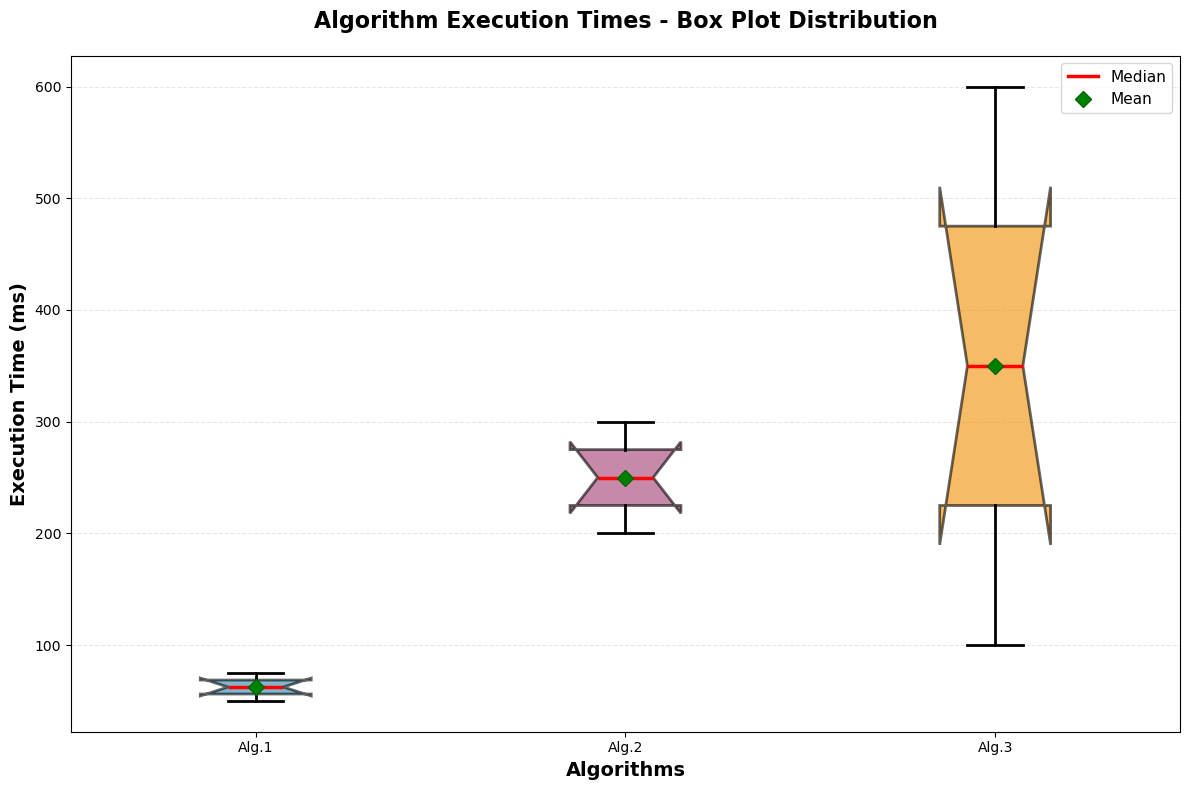


STATISTICAL SUMMARY


Algorithm  Mean  Median    Std Dev  Min  Max
    Alg.1  62.5    62.5   8.539126   50   75
    Alg.2 250.0   250.0  34.156503  200  300
    Alg.3 350.0   350.0 170.782513  100  600

PART B: Adding New Data Instructions

To add the new data row (700KB, 80, 320, 700) to the Excel file:
1. Open the Excel file: ../data/algorithm_times.xlsx
2. Add a new row with the following values:
   Data size: 700KB
   Alg.1: 80
   Alg.2: 320
   Alg.3: 700
3. Save the Excel file
4. Re-run this notebook - the charts will automatically update!

The code is designed to read ALL rows and columns dynamically,
so no code changes are needed when new data is added.

PART C: Average Execution Time for Algorithm 2

Alg.2 execution times for data sizes 100KB to 600KB:
  100KB: 200 ms
  200KB: 220 ms
  300KB: 240 ms
  400KB: 260 ms
  500KB: 280 ms
  600KB: 300 ms

Average execution time for Alg.2 (100KB-600KB): 250.00 ms

Results saved to: ../outputs/results/question2_results.txt

QUESTION 2 C

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

print("="*80)
print("QUESTION 2: Data Visualization and Analysis from Excel File")
print("="*80)

# ============================================================================
# Part A: Read Excel File and Create Visualizations
# ============================================================================
print("\n" + "="*80)
print("PART A: Reading Excel File and Creating Visualizations")
print("="*80)

# Read the Excel file
excel_file_path = '../data/algorithm_times.xlsx'

if not os.path.exists(excel_file_path):
    print(f"\nError: File not found at {excel_file_path}")
    print("Please ensure the Excel file exists in the data/ directory")
else:
    # Read the Excel file
    df = pd.read_excel(excel_file_path)
    
    print(f"\nExcel file loaded successfully from: {excel_file_path}")
    print(f"\nDataFrame shape: {df.shape[0]} rows × {df.shape[1]} columns")
    print("\nDataFrame contents:")
    print(df)
    
    # Extract data dynamically
    data_sizes = df.iloc[:, 0].values  # First column (Data size)
    alg1_times = df.iloc[:, 1].values  # Second column (Algorithm 1)
    alg2_times = df.iloc[:, 2].values  # Third column (Algorithm 2)
    alg3_times = df.iloc[:, 3].values  # Fourth column (Algorithm 3)
    
    # Get column names dynamically
    col_names = df.columns.tolist()
    data_size_label = col_names[0]
    alg1_label = col_names[1]
    alg2_label = col_names[2]
    alg3_label = col_names[3]
    
    print(f"\nColumn names detected:")
    print(f"  {data_size_label}: {data_sizes}")
    print(f"  {alg1_label}: {alg1_times}")
    print(f"  {alg2_label}: {alg2_times}")
    print(f"  {alg3_label}: {alg3_times}")
    
    # ========================================================================
    # Visualization 1: Bar Chart
    # ========================================================================
    print("\n" + "-"*80)
    print("Creating Bar Chart...")
    print("-"*80)
    
    fig, ax = plt.subplots(figsize=(14, 8))
    
    x_pos = np.arange(len(data_sizes))
    bar_width = 0.25
    
    bars1 = ax.bar(x_pos - bar_width, alg1_times, bar_width, 
                   label=alg1_label, color='#2E86AB', alpha=0.8, edgecolor='black')
    bars2 = ax.bar(x_pos, alg2_times, bar_width, 
                   label=alg2_label, color='#A23B72', alpha=0.8, edgecolor='black')
    bars3 = ax.bar(x_pos + bar_width, alg3_times, bar_width, 
                   label=alg3_label, color='#F18F01', alpha=0.8, edgecolor='black')
    
    # Add value labels on bars
    for bars in [bars1, bars2, bars3]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{int(height)}',
                   ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    ax.set_xlabel('Data Size', fontsize=14, fontweight='bold')
    ax.set_ylabel('Execution Time (ms)', fontsize=14, fontweight='bold')
    ax.set_title('Algorithm Execution Times - Bar Chart Comparison', 
                 fontsize=16, fontweight='bold', pad=20)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(data_sizes, fontsize=11)
    ax.legend(fontsize=12, loc='upper left')
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    plt.tight_layout()
    plt.savefig('../outputs/figures/question2_bar_chart.png', dpi=300, bbox_inches='tight')
    print("Bar chart saved to: ../outputs/figures/question2_bar_chart.png")
    plt.show()
    
    # ========================================================================
    # Visualization 2: Line Chart
    # ========================================================================
    print("\n" + "-"*80)
    print("Creating Line Chart...")
    print("-"*80)
    
    fig, ax = plt.subplots(figsize=(14, 8))
    
    ax.plot(data_sizes, alg1_times, marker='o', linewidth=2.5, markersize=8,
            label=alg1_label, color='#2E86AB', linestyle='-')
    ax.plot(data_sizes, alg2_times, marker='s', linewidth=2.5, markersize=8,
            label=alg2_label, color='#A23B72', linestyle='--')
    ax.plot(data_sizes, alg3_times, marker='^', linewidth=2.5, markersize=8,
            label=alg3_label, color='#F18F01', linestyle='-.')
    
    # Add value labels on points
    for i, size in enumerate(data_sizes):
        ax.annotate(f'{int(alg1_times[i])}', (size, alg1_times[i]), 
                   textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)
        ax.annotate(f'{int(alg2_times[i])}', (size, alg2_times[i]), 
                   textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)
        ax.annotate(f'{int(alg3_times[i])}', (size, alg3_times[i]), 
                   textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)
    
    ax.set_xlabel('Data Size', fontsize=14, fontweight='bold')
    ax.set_ylabel('Execution Time (ms)', fontsize=14, fontweight='bold')
    ax.set_title('Algorithm Execution Times - Line Chart Comparison', 
                 fontsize=16, fontweight='bold', pad=20)
    ax.legend(fontsize=12, loc='upper left')
    ax.grid(True, alpha=0.3, linestyle='--')
    
    plt.tight_layout()
    plt.savefig('../outputs/figures/question2_line_chart.png', dpi=300, bbox_inches='tight')
    print("Line chart saved to: ../outputs/figures/question2_line_chart.png")
    plt.show()
    
    # ========================================================================
    # Visualization 3: Box Plot
    # ========================================================================
    print("\n" + "-"*80)
    print("Creating Box Plot...")
    print("-"*80)
    
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Prepare data for box plot
    box_data = [alg1_times, alg2_times, alg3_times]
    box_labels = [alg1_label, alg2_label, alg3_label]
    
    bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True,
                    notch=True, showmeans=True,
                    boxprops=dict(facecolor='lightblue', alpha=0.7, linewidth=2),
                    whiskerprops=dict(linewidth=2),
                    capprops=dict(linewidth=2),
                    medianprops=dict(color='red', linewidth=2.5),
                    meanprops=dict(marker='D', markerfacecolor='green', 
                                  markeredgecolor='darkgreen', markersize=8))
    
    # Color each box differently
    colors = ['#2E86AB', '#A23B72', '#F18F01']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    
    ax.set_xlabel('Algorithms', fontsize=14, fontweight='bold')
    ax.set_ylabel('Execution Time (ms)', fontsize=14, fontweight='bold')
    ax.set_title('Algorithm Execution Times - Box Plot Distribution', 
                 fontsize=16, fontweight='bold', pad=20)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Add legend for mean and median
    from matplotlib.lines import Line2D
    legend_elements = [Line2D([0], [0], color='red', linewidth=2.5, label='Median'),
                      Line2D([0], [0], marker='D', color='w', 
                            markerfacecolor='green', markeredgecolor='darkgreen',
                            markersize=8, label='Mean')]
    ax.legend(handles=legend_elements, fontsize=11, loc='upper right')
    
    plt.tight_layout()
    plt.savefig('../outputs/figures/question2_box_plot.png', dpi=300, bbox_inches='tight')
    print("Box plot saved to: ../outputs/figures/question2_box_plot.png")
    plt.show()
    
    # ========================================================================
    # Statistical Summary
    # ========================================================================
    print("\n" + "="*80)
    print("STATISTICAL SUMMARY")
    print("="*80)
    
    summary_stats = pd.DataFrame({
        'Algorithm': [alg1_label, alg2_label, alg3_label],
        'Mean': [np.mean(alg1_times), np.mean(alg2_times), np.mean(alg3_times)],
        'Median': [np.median(alg1_times), np.median(alg2_times), np.median(alg3_times)],
        'Std Dev': [np.std(alg1_times), np.std(alg2_times), np.std(alg3_times)],
        'Min': [np.min(alg1_times), np.min(alg2_times), np.min(alg3_times)],
        'Max': [np.max(alg1_times), np.max(alg2_times), np.max(alg3_times)]
    })
    
    print("\n")
    print(summary_stats.to_string(index=False))
    
    # ========================================================================
    # Part B: Note for Adding New Data
    # ========================================================================
    print("\n" + "="*80)
    print("PART B: Adding New Data Instructions")
    print("="*80)
    print("\nTo add the new data row (700KB, 80, 320, 700) to the Excel file:")
    print("1. Open the Excel file: ../data/algorithm_times.xlsx")
    print("2. Add a new row with the following values:")
    print("   Data size: 700KB")
    print("   Alg.1: 80")
    print("   Alg.2: 320")
    print("   Alg.3: 700")
    print("3. Save the Excel file")
    print("4. Re-run this notebook - the charts will automatically update!")
    print("\nThe code is designed to read ALL rows and columns dynamically,")
    print("so no code changes are needed when new data is added.")
    
    # ========================================================================
    # Part C: Calculate Average for Algorithm 2 (100-600KB data only)
    # ========================================================================
    print("\n" + "="*80)
    print("PART C: Average Execution Time for Algorithm 2")
    print("="*80)
    
    # Filter data for 100KB to 600KB (exclude 700KB if present)
    # Convert data_sizes to numeric format for comparison
    data_sizes_numeric = []
    for size in data_sizes:
        # Extract numeric value from string (e.g., "100KB" -> 100)
        numeric_val = int(''.join(filter(str.isdigit, str(size))))
        data_sizes_numeric.append(numeric_val)
    
    # Get indices where data size is between 100 and 600
    indices_100_600 = [i for i, size in enumerate(data_sizes_numeric) if 100 <= size <= 600]
    
    # Extract Algorithm 2 times for 100-600KB range
    alg2_times_filtered = [alg2_times[i] for i in indices_100_600]
    
    print(f"\n{alg2_label} execution times for data sizes 100KB to 600KB:")
    for i in indices_100_600:
        print(f"  {data_sizes[i]}: {alg2_times[i]} ms")
    
    # Calculate average
    avg_alg2 = np.mean(alg2_times_filtered)
    
    print(f"\nAverage execution time for {alg2_label} (100KB-600KB): {avg_alg2:.2f} ms")
    
    # Save results to text file
    with open('../outputs/results/question2_results.txt', 'w') as f:
        f.write("="*80 + "\n")
        f.write("QUESTION 2: ANALYSIS RESULTS\n")
        f.write("="*80 + "\n\n")
        
        f.write("PART A: Data Summary\n")
        f.write("-"*80 + "\n")
        f.write(df.to_string(index=False))
        f.write("\n\n")
        
        f.write("Statistical Summary:\n")
        f.write(summary_stats.to_string(index=False))
        f.write("\n\n")
        
        f.write("PART C: Algorithm 2 Average (100KB-600KB)\n")
        f.write("-"*80 + "\n")
        f.write(f"Average execution time: {avg_alg2:.2f} ms\n")
        f.write(f"Number of data points: {len(alg2_times_filtered)}\n")
        f.write(f"Data range: {data_sizes[indices_100_600[0]]} to {data_sizes[indices_100_600[-1]]}\n")
    
    print("\nResults saved to: ../outputs/results/question2_results.txt")
    
    print("\n" + "="*80)
    print("QUESTION 2 COMPLETED SUCCESSFULLY")
    print("="*80)